
# Paso 07 · Validación temporal del modelo ganador

El Paso 06 seleccionó **SVM con kernel RBF** como ganador mediante validación cruzada temporal exclusivamente sobre 1991–2017.

Configuración congelada:

- `C = 1`
- `gamma = 0.05`
- `kernel = rbf`
- selector numérico: `k = all`

En este paso **NO se vuelve a buscar hiperparámetros**.

Se entrena una única vez con todo el split `entrenamiento` y se evalúa una única vez en:

\[
\text{validacion temporal} = 2018\text{–}2021
\]

El test 2022–2025 y el holdout espacial continúan sin utilizarse.

## Regla principal

Los resultados de validación sirven para confirmar que la configuración seleccionada en CV generaliza razonablemente. **No se utilizarán para iniciar otra búsqueda de hiperparámetros.**


In [1]:

from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CLASS_ORDER = ["Baja", "Media", "Alta"]

TARGET_TO_INT = {
    "Baja": 0,
    "Media": 1,
    "Alta": 2,
}

INT_TO_TARGET = {
    value: key
    for key, value in TARGET_TO_INT.items()
}

BASE_DIR = Path.cwd()
while not (BASE_DIR / "zonas_era5_ecuador.csv").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "zonas_era5_ecuador.csv").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")

DATA_FILE = (
    BASE_DIR
    / "datos"
    / "modelado"
    / "dataset_caracteristicas_candidatas.csv"
)

CATALOG_FILE = (
    BASE_DIR
    / "resultados"
    / "analisis_caracteristicas"
    / "catalogo_caracteristicas_modelado.csv"
)

STEP06_RESULTS = (
    BASE_DIR
    / "resultados"
    / "modelos_cv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "resultados"
    / "validacion_modelo"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_FILE}")
print(f"Catálogo: {CATALOG_FILE}")
print(f"Resultados Paso 06: {STEP06_RESULTS}")
print(f"Salida: {OUTPUT_DIR}")


Dataset: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\datos\modelado\dataset_caracteristicas_candidatas.csv
Catálogo: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\analisis_caracteristicas\catalogo_caracteristicas_modelado.csv
Resultados Paso 06: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\modelos_cv
Salida: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\validacion_modelo



## 1. Confirmar que el ganador del Paso 06 es SVM

El notebook lee `ganador_paso06.json` si existe y aborta si alguien intenta ejecutar el Paso 07 con una configuración diferente sin dejarlo explícito.

La humanidad ya produjo suficientes modelos "final_v2_ahora_si.joblib".


In [2]:

WINNER_FILE = STEP06_RESULTS / "ganador_paso06.json"
PARAMS_FILE = STEP06_RESULTS / "mejores_parametros.json"

if not PARAMS_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró {PARAMS_FILE}. Ejecuta primero el Paso 06."
    )

with PARAMS_FILE.open("r", encoding="utf-8") as file:
    all_params = json.load(file)

svm_params = all_params["SVM_RBF"]

EXPECTED_SVM_PARAMS = {
    "model__C": 1,
    "model__gamma": 0.05,
    "preprocess__num__selector__k": "all",
}

if svm_params != EXPECTED_SVM_PARAMS:
    raise ValueError(
        "La configuración de SVM no coincide con la validada en el Paso 06.\n"
        f"Esperado: {EXPECTED_SVM_PARAMS}\n"
        f"Encontrado: {svm_params}"
    )

if WINNER_FILE.exists():
    with WINNER_FILE.open("r", encoding="utf-8") as file:
        winner_payload = json.load(file)

    if winner_payload["modelo_ganador"] != "SVM_RBF":
        raise ValueError(
            "El ganador registrado en Paso 06 no es SVM_RBF: "
            f"{winner_payload['modelo_ganador']}"
        )

    print(
        "Ganador registrado:",
        winner_payload["modelo_ganador"],
    )
    print(
        "Macro F1 CV:",
        round(
            winner_payload["macro_f1_cv_media"],
            4,
        ),
    )

print("Configuración SVM congelada:", svm_params)


Ganador registrado: SVM_RBF
Macro F1 CV: 0.7188
Configuración SVM congelada: {'model__C': 1, 'model__gamma': 0.05, 'preprocess__num__selector__k': 'all'}



## 2. Cargar predictors exclusivamente desde el catálogo

No se construye `X` eliminando columnas "a ojo". La lista permitida sale del catálogo del Paso 05 y vuelve a pasar por una barrera anti-leakage.


In [3]:

if not DATA_FILE.exists():
    raise FileNotFoundError(DATA_FILE)

if not CATALOG_FILE.exists():
    raise FileNotFoundError(CATALOG_FILE)

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
)

catalog = pd.read_csv(
    CATALOG_FILE,
    encoding="utf-8-sig",
)

df["period_start"] = pd.to_datetime(
    df["period_start"]
)
df["target_period_start"] = pd.to_datetime(
    df["target_period_start"]
)

FEATURES = catalog["caracteristica"].tolist()

NUMERIC_FEATURES = catalog.loc[
    catalog["tipo"] == "numerica",
    "caracteristica",
].tolist()

CATEGORICAL_FEATURES = catalog.loc[
    catalog["tipo"] == "categorica",
    "caracteristica",
].tolist()

FORBIDDEN = {
    "target_amenaza",
    "target_rx5day_mm",
    "target_period_start",
    "amenaza_mes",
    "split",
    "rol",
    "zone_id",
    "ciudad",
    "provincia",
    "period",
    "period_start",
}

leakage = sorted(
    set(FEATURES).intersection(FORBIDDEN)
)

if leakage:
    raise RuntimeError(
        f"LEAKAGE detectado: {leakage}"
    )

missing = sorted(
    set(FEATURES).difference(df.columns)
)

if missing:
    raise ValueError(
        f"Features ausentes: {missing}"
    )

train = (
    df[df["split"] == "entrenamiento"]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

validation = (
    df[
        df["split"]
        == "validacion_temporal"
    ]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

print(f"Train: {len(train):,}")
print(f"Validación 2018–2021: {len(validation):,}")
print(f"Features oficiales: {len(FEATURES)}")
print(
    f"Numéricas: {len(NUMERIC_FEATURES)} | "
    f"Categóricas: {len(CATEGORICAL_FEATURES)}"
)


Train: 3,744
Validación 2018–2021: 576
Features oficiales: 38
Numéricas: 37 | Categóricas: 1



## 3. Reconstruir exactamente el Pipeline ganador

La configuración del Paso 06 usó todas las 37 variables numéricas candidatas y `region` mediante one-hot.

Esto significa que el análisis previo ya hizo la reducción importante: **38 candidatas en lugar de las 192 de los experimentos antiguos**. El CV no encontró beneficio adicional en reducirlas para SVM.


In [4]:

def mutual_information_scores(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE,
    )


def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


numeric_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "selector",
            SelectKBest(
                score_func=mutual_information_scores,
                k="all",
            ),
        ),
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "onehot",
            make_onehot_encoder(),
        ),
    ]
)

preprocessor = ColumnTransformer(
    [
        (
            "num",
            numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

pipeline = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "model",
            SVC(
                kernel="rbf",
                C=1,
                gamma=0.05,
            ),
        ),
    ]
)

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o


## 4. Entrenar una vez con 1991–2017 y validar una vez en 2018–2021


In [5]:

X_train = train[FEATURES].copy()
y_train = (
    train["target_amenaza"]
    .map(TARGET_TO_INT)
    .astype(int)
)

X_val = validation[FEATURES].copy()
y_val = (
    validation["target_amenaza"]
    .map(TARGET_TO_INT)
    .astype(int)
)

start = time.perf_counter()

pipeline.fit(
    X_train,
    y_train,
)

fit_time = time.perf_counter() - start

start = time.perf_counter()

pred_val = pipeline.predict(
    X_val
)

inference_time = time.perf_counter() - start

print(
    f"Entrenamiento: {fit_time:.3f} s"
)
print(
    f"Inferencia 576 filas: "
    f"{inference_time:.3f} s"
)


Entrenamiento: 0.764 s
Inferencia 576 filas: 0.088 s



## 5. Métricas de validación

Macro F1 sigue siendo la métrica principal. Recall de `Alta` es la secundaria crítica.


In [6]:

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_val,
        pred_val,
        labels=[0, 1, 2],
        zero_division=0,
    )
)

metrics = {
    "modelo": "SVM_RBF",
    "macro_f1": f1_score(
        y_val,
        pred_val,
        average="macro",
        zero_division=0,
    ),
    "balanced_accuracy": (
        balanced_accuracy_score(
            y_val,
            pred_val,
        )
    ),
    "accuracy": accuracy_score(
        y_val,
        pred_val,
    ),
    "precision_baja": precision[0],
    "recall_baja": recall[0],
    "f1_baja": f1[0],
    "support_baja": int(support[0]),
    "precision_media": precision[1],
    "recall_media": recall[1],
    "f1_media": f1[1],
    "support_media": int(support[1]),
    "precision_alta": precision[2],
    "recall_alta": recall[2],
    "f1_alta": f1[2],
    "support_alta": int(support[2]),
    "fit_time_seg": fit_time,
    "inference_time_seg": inference_time,
}

metrics_df = pd.DataFrame(
    [metrics]
)

metrics_df.to_csv(
    OUTPUT_DIR
    / "metricas_validacion_svm.csv",
    index=False,
    encoding="utf-8-sig",
)

metrics_df.T


,0
modelo,SVM_RBF
macro_f1,0.689452
balanced_accuracy,0.689196
accuracy,0.699653
precision_baja,0.837563
recall_baja,0.767442
f1_baja,0.800971
support_baja,215
precision_media,0.475936
recall_media,0.597315


In [7]:

report = classification_report(
    y_val,
    pred_val,
    labels=[0, 1, 2],
    target_names=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

report_df = (
    pd.DataFrame(report)
    .T
)

report_df.to_csv(
    OUTPUT_DIR
    / "reporte_clasificacion_validacion.csv",
    encoding="utf-8-sig",
)

report_df


,precision,recall,f1-score,support
Baja,0.837563,0.767442,0.800971,215.000000
Media,0.475936,0.597315,0.529762,149.000000
Alta,0.776042,0.702830,0.737624,212.000000
accuracy,0.699653,0.699653,0.699653,0.699653
macro avg,0.696514,0.689196,0.689452,576.000000
weighted avg,0.721374,0.699653,0.707499,576.000000



## 6. Matriz de confusión


In [8]:

cm = confusion_matrix(
    y_val,
    pred_val,
    labels=[0, 1, 2],
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"real_{name}"
        for name in CLASS_ORDER
    ],
    columns=[
        f"pred_{name}"
        for name in CLASS_ORDER
    ],
)

cm_df.to_csv(
    OUTPUT_DIR
    / "matriz_confusion_validacion.csv",
    encoding="utf-8-sig",
)

cm_df


,pred_Baja,pred_Media,pred_Alta
real_Baja,165,43,7
real_Media,24,89,36
real_Alta,8,55,149


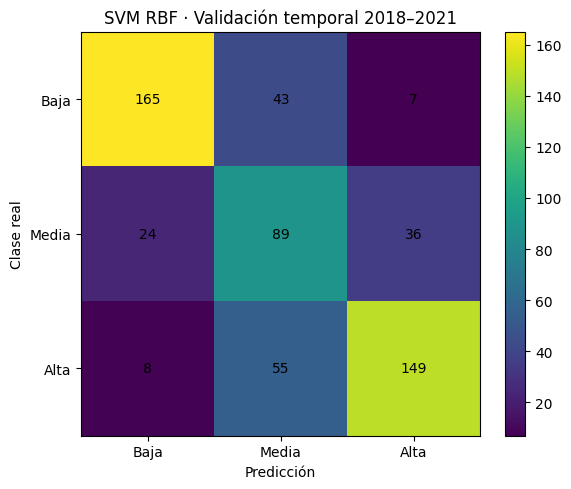

In [9]:

plt.figure(figsize=(6, 5))

image = plt.imshow(
    cm,
    aspect="auto",
)

plt.colorbar(image)

plt.xticks(
    range(3),
    CLASS_ORDER,
)

plt.yticks(
    range(3),
    CLASS_ORDER,
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title(
    "SVM RBF · Validación temporal 2018–2021"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "01_matriz_confusion_validacion.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()



## 7. Baselines en el mismo periodo de validación

Los baselines se construyen usando únicamente 1991–2017 para definir sus reglas y se comparan sobre las mismas 576 filas.

- Dummy: clase mayoritaria del entrenamiento.
- Persistencia: `amenaza_mes(t)`.
- Climatología mensual: clase más frecuente por mes objetivo en entrenamiento.


In [10]:

def metric_row(
    name,
    y_true,
    y_pred,
):
    p, r, f, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            zero_division=0,
        )
    )

    return {
        "modelo": name,
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "recall_alta": r[2],
        "f1_baja": f[0],
        "f1_media": f[1],
        "f1_alta": f[2],
    }


baseline_rows = []

# Dummy
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    np.zeros((len(y_train), 1)),
    y_train,
)

pred_dummy = dummy.predict(
    np.zeros((len(y_val), 1))
)

baseline_rows.append(
    metric_row(
        "Dummy_most_frequent",
        y_val,
        pred_dummy,
    )
)

# Persistencia
pred_persistence = (
    validation["amenaza_mes"]
    .map(TARGET_TO_INT)
    .astype(int)
    .to_numpy()
)

baseline_rows.append(
    metric_row(
        "Persistencia",
        y_val,
        pred_persistence,
    )
)

# Climatología mensual aprendida SOLO en train
train_month_class = (
    train.assign(
        target_int=(
            train["target_amenaza"]
            .map(TARGET_TO_INT)
            .astype(int)
        )
    )
    .groupby("target_month")[
        "target_int"
    ]
    .agg(
        lambda s: s.value_counts().idxmax()
    )
    .to_dict()
)

majority = (
    y_train.value_counts().idxmax()
)

pred_climatology = (
    validation["target_month"]
    .map(train_month_class)
    .fillna(majority)
    .astype(int)
    .to_numpy()
)

baseline_rows.append(
    metric_row(
        "Climatologia_mes",
        y_val,
        pred_climatology,
    )
)

baseline_df = pd.DataFrame(
    baseline_rows
)

comparison = pd.concat(
    [
        metrics_df[
            [
                "modelo",
                "macro_f1",
                "balanced_accuracy",
                "accuracy",
                "recall_alta",
                "f1_baja",
                "f1_media",
                "f1_alta",
            ]
        ],
        baseline_df,
    ],
    ignore_index=True,
)

comparison = comparison.sort_values(
    "macro_f1",
    ascending=False,
)

comparison.to_csv(
    OUTPUT_DIR
    / "comparacion_validacion_baselines.csv",
    index=False,
    encoding="utf-8-sig",
)

comparison


,modelo,macro_f1,balanced_accuracy,accuracy,recall_alta,f1_baja,f1_media,f1_alta
0,SVM_RBF,0.689452,0.689196,0.699653,0.702830,0.800971,0.529762,0.737624
2,Persistencia,0.612673,0.612779,0.637153,0.702830,0.739535,0.397306,0.701176
3,Climatologia_mes,0.438632,0.515094,0.572917,0.745283,0.683897,0.000000,0.632000
1,Dummy_most_frequent,0.179357,0.333333,0.368056,1.000000,0.000000,0.000000,0.538071



## 8. Comparación contra el resultado esperado por CV

Una validación razonable no tiene por qué producir exactamente el mismo valor que el promedio CV. Aquí solo verificamos cuánto cambia.

No se inicia nuevo tuning a partir de esta diferencia.


In [11]:

CV_SUMMARY_FILE = (
    STEP06_RESULTS
    / "comparacion_modelos_cv.csv"
)

if CV_SUMMARY_FILE.exists():
    cv_summary = pd.read_csv(
        CV_SUMMARY_FILE,
        encoding="utf-8-sig",
    )

    svm_cv = cv_summary[
        cv_summary["modelo"]
        == "SVM_RBF"
    ].iloc[0]

    cv_macro = float(
        svm_cv["macro_f1_media"]
    )

    validation_macro = float(
        metrics["macro_f1"]
    )

    delta = (
        validation_macro
        - cv_macro
    )

    comparison_cv_val = pd.DataFrame(
        [
            {
                "metrica": "macro_f1",
                "cv_temporal_1991_2017": cv_macro,
                "validacion_2018_2021": validation_macro,
                "diferencia_validacion_menos_cv": delta,
            },
            {
                "metrica": "balanced_accuracy",
                "cv_temporal_1991_2017": float(
                    svm_cv[
                        "balanced_accuracy_media"
                    ]
                ),
                "validacion_2018_2021": float(
                    metrics[
                        "balanced_accuracy"
                    ]
                ),
                "diferencia_validacion_menos_cv": (
                    float(
                        metrics[
                            "balanced_accuracy"
                        ]
                    )
                    - float(
                        svm_cv[
                            "balanced_accuracy_media"
                        ]
                    )
                ),
            },
            {
                "metrica": "recall_alta",
                "cv_temporal_1991_2017": float(
                    svm_cv[
                        "recall_alta_media"
                    ]
                ),
                "validacion_2018_2021": float(
                    metrics[
                        "recall_alta"
                    ]
                ),
                "diferencia_validacion_menos_cv": (
                    float(
                        metrics[
                            "recall_alta"
                        ]
                    )
                    - float(
                        svm_cv[
                            "recall_alta_media"
                        ]
                    )
                ),
            },
        ]
    )

    comparison_cv_val.to_csv(
        OUTPUT_DIR
        / "comparacion_cv_vs_validacion.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(comparison_cv_val)


,metrica,cv_temporal_1991_2017,validacion_2018_2021,diferencia_validacion_menos_cv
0,macro_f1,0.718816,0.689452,-0.029364
1,balanced_accuracy,0.718017,0.689196,-0.028821
2,recall_alta,0.713087,0.702830,-0.010257



## 9. Guardar predicciones de validación

Estas predicciones permiten revisar errores por zona o por mes sin alterar la configuración del modelo.


In [12]:

predictions = validation[
    [
        "zone_id",
        "ciudad",
        "region",
        "period_start",
        "target_period_start",
        "target_rx5day_mm",
        "amenaza_mes",
        "target_amenaza",
    ]
].copy()

predictions["prediccion"] = [
    INT_TO_TARGET[
        int(value)
    ]
    for value in pred_val
]

predictions[
    "correcta"
] = (
    predictions["target_amenaza"]
    == predictions["prediccion"]
)

predictions.to_csv(
    OUTPUT_DIR
    / "predicciones_validacion_2018_2021.csv",
    index=False,
    encoding="utf-8-sig",
)

predictions.head()


,zone_id,ciudad,region,period_start,target_period_start,target_rx5day_mm,amenaza_mes,target_amenaza,prediccion,correcta
0,babahoyo,Babahoyo,Litoral,2017-12-01,2018-01-01,69.510217,Media,Media,Alta,False
1,cuenca,Cuenca,Sierra,2017-12-01,2018-01-01,63.223913,Alta,Media,Media,True
2,esmeraldas,Esmeraldas,Litoral,2017-12-01,2018-01-01,41.781802,Baja,Media,Alta,False
3,guayaquil,Guayaquil,Litoral,2017-12-01,2018-01-01,46.285503,Media,Media,Alta,False
4,loja,Loja,Sierra,2017-12-01,2018-01-01,78.506386,Alta,Alta,Media,False



## 10. Resultado del Paso 07

La configuración queda **congelada** después de esta validación.

Si el desempeño es razonablemente consistente con el CV y supera de forma clara los baselines, el siguiente paso será la evaluación final.

En el Paso 08 se preservará la separación:

### Evaluación temporal final
Entrenar con las zonas de desarrollo hasta 2021 y evaluar en 2022–2025.

### Evaluación espacial
Evaluar la capacidad de generalización hacia las tres zonas reservadas sin utilizarlas para ajustar el modelo.

La calibración de probabilidades para el prototipo se realizará después de fijar la evaluación clasificatoria final; no se modifica ahora el SVM ganador.


In [13]:

best_baseline = (
    comparison[
        comparison["modelo"]
        != "SVM_RBF"
    ]
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .iloc[0]
)

print("PASO 07 · RESULTADO")
print("-------------------")
print(
    f"SVM Macro F1: "
    f"{metrics['macro_f1']:.4f}"
)
print(
    f"Balanced Accuracy: "
    f"{metrics['balanced_accuracy']:.4f}"
)
print(
    f"Recall Alta: "
    f"{metrics['recall_alta']:.4f}"
)
print(
    f"F1 Baja / Media / Alta: "
    f"{metrics['f1_baja']:.4f} / "
    f"{metrics['f1_media']:.4f} / "
    f"{metrics['f1_alta']:.4f}"
)

print(
    f"\nMejor baseline: "
    f"{best_baseline['modelo']} "
    f"(Macro F1 "
    f"{best_baseline['macro_f1']:.4f})"
)

print(
    f"Mejora absoluta: "
    f"{metrics['macro_f1'] - best_baseline['macro_f1']:+.4f}"
)

print(
    "\nConfiguración congelada. "
    "No se realizó tuning con 2018–2021."
)
print(
    "Test 2022–2025 y holdout espacial "
    "siguen sin evaluarse."
)


PASO 07 · RESULTADO
-------------------
SVM Macro F1: 0.6895
Balanced Accuracy: 0.6892
Recall Alta: 0.7028
F1 Baja / Media / Alta: 0.8010 / 0.5298 / 0.7376

Mejor baseline: Persistencia (Macro F1 0.6127)
Mejora absoluta: +0.0768

Configuración congelada. No se realizó tuning con 2018–2021.
Test 2022–2025 y holdout espacial siguen sin evaluarse.
